# Cointegration Analysis: GLD/GDX ETF Pair

Testing for long-run equilibrium relationships between gold (GLD) and gold miners (GDX) using the Engle-Granger two-step procedure. Foundation for statistical arbitrage strategy development.

## Data
- ETF pair: GLD (SPDR Gold Trust) / GDX (VanEck Gold Miners ETF)
- Daily close prices via yfinance
- Period: 2019-2025

## 1. Price Series and Visual Inspection

[*********************100%***********************]  1 of 1 completed

[*********************100%***********************]  1 of 1 completed

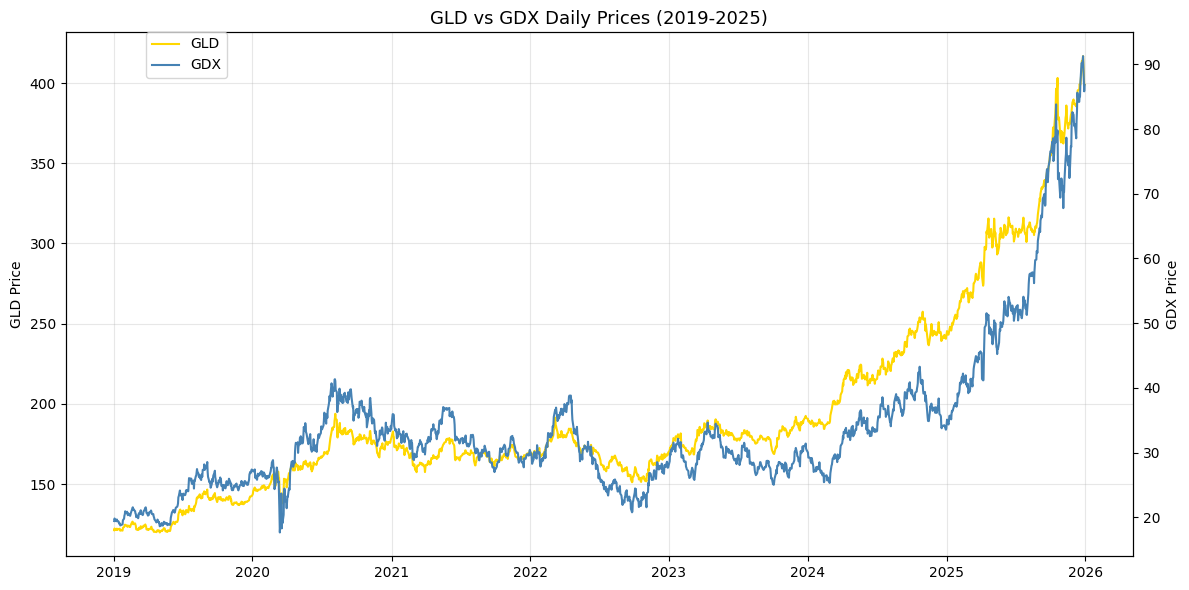

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs('figures', exist_ok=True)

gld = yf.download('GLD', start='2019-01-01', end='2025-12-31')
gdx = yf.download('GDX', start='2019-01-01', end='2025-12-31')

gld.columns = gld.columns.get_level_values(0)
gdx.columns = gdx.columns.get_level_values(0)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(gld.index, gld['Close'], label='GLD', color='gold')
ax2 = ax1.twinx()
ax2.plot(gdx.index, gdx['Close'], label='GDX', color='steelblue')
ax1.set_ylabel('GLD Price')
ax2.set_ylabel('GDX Price')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.95))
plt.title('GLD vs GDX Daily Prices (2019-2025)', fontsize=13)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/gld_gdx_prices.png', dpi=150)
plt.show()

## 2. Stationarity Testing (ADF on Individual Series)

In [2]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f'ADF Test: {name}')
    print(f'  Test Statistic: {result[0]:.4f}')
    print(f'  p-value: {result[1]:.4f}')
    print(f'  Lags Used: {result[2]}')
    print(f'  Stationary: {"Yes" if result[1] < 0.05 else "No"}')
    print()

adf_test(gld['Close'], 'GLD Price Level')
adf_test(gdx['Close'], 'GDX Price Level')

ADF Test: GLD Price Level
  Test Statistic: 3.3786
  p-value: 1.0000
  Lags Used: 7
  Stationary: No

ADF Test: GDX Price Level
  Test Statistic: 2.2698
  p-value: 0.9989
  Lags Used: 25
  Stationary: No



### ADF Results
- GLD: Test Statistic = 3.379, p-value = 1.000. Non-stationary.
- GDX: Test Statistic = 2.270, p-value = 0.999. Non-stationary.

Both series are clearly non-stationary (positive test statistics, p-values at 1.0). This is a necessary condition for cointegration: if a linear combination of two non-stationary series is stationary, they are cointegrated.


## 3. Spread Construction

Beta: 0.1906
Intercept: -3.1914
R-squared: 0.8776


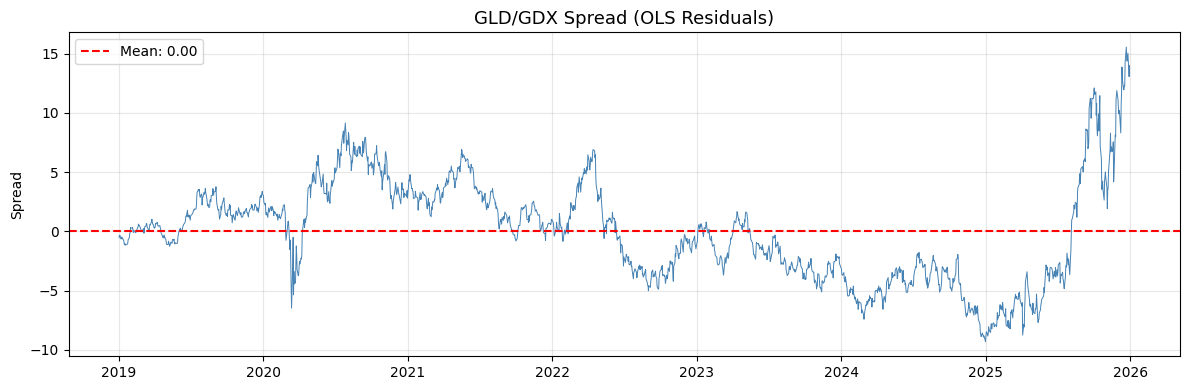

In [3]:
import statsmodels.api as sm

X = sm.add_constant(gld['Close'])
model = sm.OLS(gdx['Close'], X).fit()
print(f'Beta: {model.params.iloc[1]:.4f}')
print(f'Intercept: {model.params.iloc[0]:.4f}')
print(f'R-squared: {model.rsquared:.4f}')

spread = gdx['Close'] - model.params.iloc[1] * gld['Close'] - model.params.iloc[0]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(spread.index, spread, color='steelblue', linewidth=0.7)
ax.axhline(y=spread.mean(), color='red', linestyle='--', label=f'Mean: {spread.mean():.2f}')
ax.set_title('GLD/GDX Spread (OLS Residuals)', fontsize=13)
ax.set_ylabel('Spread')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/gld_gdx_spread.png', dpi=150)
plt.show()

## 4. Engle-Granger Two-Step Test
### Step 1: OLS Regression
Completed above. GDX regressed on GLD.

### Step 2: ADF Test on Residuals
If the spread (OLS residuals) is stationary, the two series are cointegrated.

In [4]:
adf_test(spread, 'GLD/GDX Spread (OLS Residuals)')

ADF Test: GLD/GDX Spread (OLS Residuals)
  Test Statistic: -1.5608
  p-value: 0.5032
  Lags Used: 20
  Stationary: No



### Engle-Granger Result
The ADF test on the OLS spread residuals determines whether GLD and GDX share a long-run equilibrium. A stationary spread (p-value < 0.05) would confirm cointegration — meaning deviations from the equilibrium relationship are temporary and mean-reverting.

With p > 0.05, the spread is non-stationary over this full sample period, suggesting the cointegration relationship is weak or unstable. This motivates rolling-window analysis below to check whether cointegration holds in subperiods.

## 5. Half-Life of Mean Reversion
The half-life measures how quickly the spread reverts to its mean. We regress spread changes on the lagged spread level:

$$\Delta S_t = \lambda \cdot S_{t-1} + \epsilon_t$$

The half-life is $h = -\ln(2) / \lambda$. A shorter half-life implies faster mean reversion and more frequent trading opportunities.

In [5]:
spread_lag = spread.shift(1)
spread_diff = spread.diff()

spread_lag_clean = spread_lag.dropna()
spread_diff_clean = spread_diff.loc[spread_lag_clean.index]

X_hl = sm.add_constant(spread_lag_clean)
model_hl = sm.OLS(spread_diff_clean, X_hl).fit()

lam = model_hl.params.iloc[1]
half_life = -np.log(2) / lam

print(f'Lambda (mean reversion coefficient): {lam:.6f}')
print(f'Half-life of mean reversion: {half_life:.1f} days')
print(f'p-value on lambda: {model_hl.pvalues.iloc[1]:.4f}')

if lam < 0 and model_hl.pvalues.iloc[1] < 0.05:
    print(f'\nThe spread mean-reverts with a half-life of ~{half_life:.0f} trading days.')
elif lam < 0:
    print(f'\nLambda is negative (mean-reverting) but not statistically significant (p={model_hl.pvalues.iloc[1]:.3f}).')
else:
    print('\nLambda is non-negative — no evidence of mean reversion.')

Lambda (mean reversion coefficient): -0.006044
Half-life of mean reversion: 114.7 days
p-value on lambda: 0.0612

Lambda is negative (mean-reverting) but not statistically significant (p=0.061).


## 6. Rolling Cointegration
Full-sample cointegration tests can mask time-varying relationships. A 252-day (1 trading year) rolling window re-runs the Engle-Granger ADF test at each point to assess whether cointegration holds consistently or only in certain regimes.

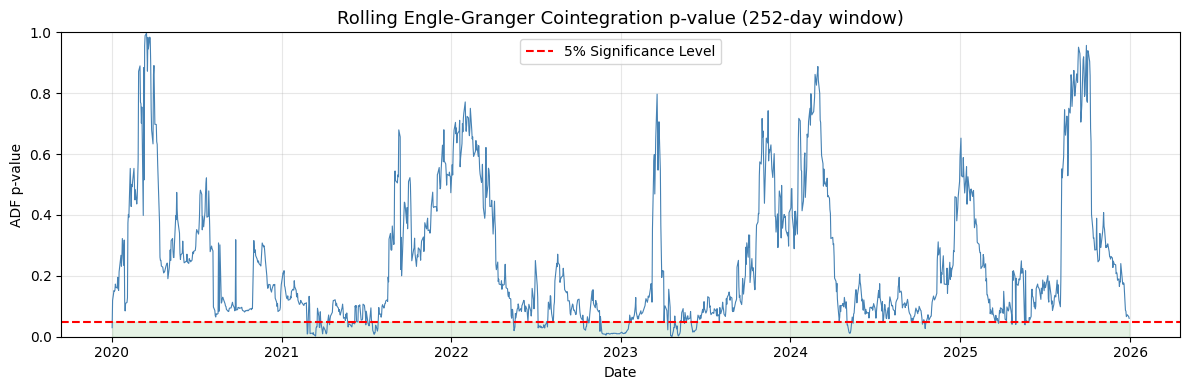

Percentage of windows with p < 0.05: 11.5%


In [6]:
window = 252
rolling_pvalues = []
rolling_dates = []

for i in range(window, len(gld)):
    gld_window = gld['Close'].iloc[i - window:i]
    gdx_window = gdx['Close'].iloc[i - window:i]

    X_roll = sm.add_constant(gld_window)
    model_roll = sm.OLS(gdx_window, X_roll).fit()
    spread_roll = gdx_window - model_roll.predict(X_roll)

    adf_result = adfuller(spread_roll.dropna(), autolag='AIC')
    rolling_pvalues.append(adf_result[1])
    rolling_dates.append(gld.index[i])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rolling_dates, rolling_pvalues, color='steelblue', linewidth=0.8)
ax.axhline(y=0.05, color='red', linestyle='--', label='5% Significance Level')
ax.fill_between(rolling_dates, 0, 0.05, alpha=0.1, color='green')
ax.set_title('Rolling Engle-Granger Cointegration p-value (252-day window)', fontsize=13)
ax.set_ylabel('ADF p-value')
ax.set_xlabel('Date')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/gld_gdx_rolling_coint.png', dpi=150)
plt.show()

pct_significant = sum(1 for p in rolling_pvalues if p < 0.05) / len(rolling_pvalues) * 100
print(f'Percentage of windows with p < 0.05: {pct_significant:.1f}%')

### Rolling Cointegration Interpretation
The green-shaded region marks periods where the rolling ADF p-value falls below 0.05 (cointegration detected). Periods above the red line indicate the relationship has broken down.

This time-varying view is critical for pairs trading: a pair may be cointegrated in certain market regimes but not others. Trading strategies should monitor rolling cointegration and pause when the relationship weakens.

## 7. Rolling Cointegration Stability Analysis
A rolling hedge ratio reveals whether the equilibrium relationship between GLD and GDX is structurally stable or drifts over time. We compute the OLS beta and ADF test statistic in a 252-day rolling window and compare against full-sample estimates.

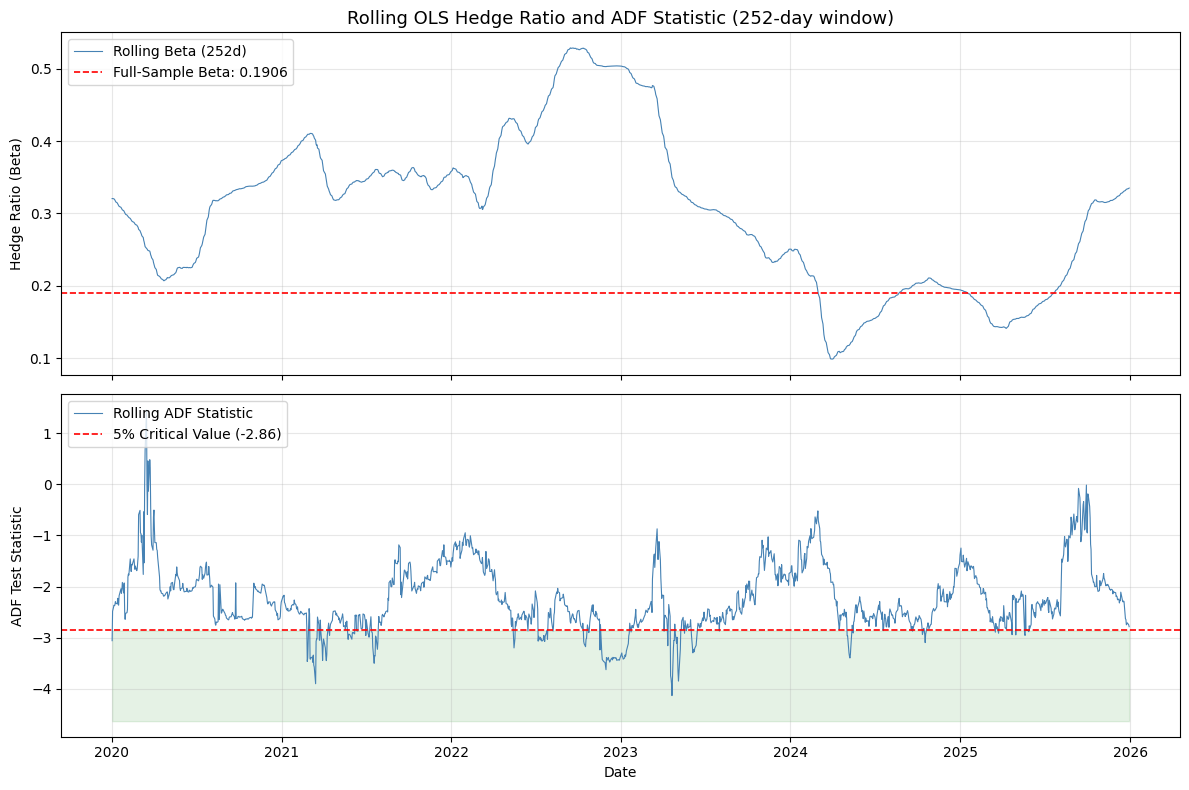

Rolling beta range: 0.0986 to 0.5291 (spread: 0.4305)
Full-sample beta: 0.1906
Percentage of windows with ADF statistic < -2.86: 11.6%


In [7]:
full_sample_beta = model.params.iloc[1]

rolling_betas = []
rolling_adf_stats = []
rolling_dates_stability = []

for i in range(window, len(gld)):
    gld_window = gld['Close'].iloc[i - window:i]
    gdx_window = gdx['Close'].iloc[i - window:i]

    X_roll = sm.add_constant(gld_window)
    model_roll = sm.OLS(gdx_window, X_roll).fit()
    rolling_betas.append(model_roll.params.iloc[1])

    spread_roll = gdx_window - model_roll.predict(X_roll)
    adf_result = adfuller(spread_roll.dropna(), autolag='AIC')
    rolling_adf_stats.append(adf_result[0])
    rolling_dates_stability.append(gld.index[i])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(rolling_dates_stability, rolling_betas, color='steelblue', linewidth=0.8, label='Rolling Beta (252d)')
ax1.axhline(y=full_sample_beta, color='red', linestyle='--', linewidth=1.2,
            label=f'Full-Sample Beta: {full_sample_beta:.4f}')
ax1.set_ylabel('Hedge Ratio (Beta)')
ax1.set_title('Rolling OLS Hedge Ratio and ADF Statistic (252-day window)', fontsize=13)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2.plot(rolling_dates_stability, rolling_adf_stats, color='steelblue', linewidth=0.8, label='Rolling ADF Statistic')
ax2.axhline(y=-2.86, color='red', linestyle='--', linewidth=1.2, label='5% Critical Value (-2.86)')
ax2.fill_between(rolling_dates_stability, min(rolling_adf_stats) - 0.5, -2.86, alpha=0.1, color='green')
ax2.set_ylabel('ADF Test Statistic')
ax2.set_xlabel('Date')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/gld_gdx_rolling_stability.png', dpi=150)
plt.show()

pct_below_cv = sum(1 for s in rolling_adf_stats if s < -2.86) / len(rolling_adf_stats) * 100
beta_range = max(rolling_betas) - min(rolling_betas)
print(f'Rolling beta range: {min(rolling_betas):.4f} to {max(rolling_betas):.4f} (spread: {beta_range:.4f})')
print(f'Full-sample beta: {full_sample_beta:.4f}')
print(f'Percentage of windows with ADF statistic < -2.86: {pct_below_cv:.1f}%')

### Stability Analysis Interpretation
The rolling hedge ratio is not constant — it drifts substantially over the sample period, indicating that the equilibrium relationship between GLD and GDX is structurally unstable. A pairs trading strategy using a fixed hedge ratio calibrated on the full sample would accumulate tracking error as beta shifts.

The rolling ADF statistic confirms this instability. Cointegration (ADF below the -2.86 critical value) holds only intermittently, with extended periods where the spread is indistinguishable from a random walk. This is consistent with regime-dependent cointegration: the gold-miner relationship strengthens when both assets are driven by a common gold price factor, but weakens when idiosyncratic forces (e.g., miner cost inflation, equity beta, operational risk) dominate GDX pricing.

**Implication for trading:** A static Engle-Granger pairs strategy on GLD/GDX would require an adaptive hedge ratio and a cointegration filter that pauses trading when rolling ADF statistics rise above the critical value. Without these safeguards, the strategy risks trading a non-mean-reverting spread.

## Key Findings

1. **No full-sample cointegration.** The Engle-Granger ADF test on the GLD/GDX spread fails to reject the null (p=0.503). The full-sample spread is non-stationary.
2. **Weak mean reversion.** The half-life estimate is ~115 trading days with lambda marginally insignificant (p=0.061). Even if mean-reverting, the reversion is too slow for most pairs trading strategies.
3. **Unstable hedge ratio.** The rolling OLS beta ranges from ~0.10 to ~0.53 around the full-sample estimate of 0.19. A fixed hedge ratio would produce large tracking error.
4. **Regime-dependent cointegration.** Only ~12% of rolling 252-day windows show cointegration at the 5% level. The relationship holds intermittently, breaking down for extended periods.
5. **Implication for stat arb.** A GLD/GDX pairs strategy requires adaptive hedge ratios and a cointegration filter. Static Engle-Granger calibration is insufficient — the pair is not reliably cointegrated over this sample.